In [7]:

pip install catboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached catboost-1.2.10-cp312-cp312-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached catboost-1.2.10-cp312-cp312-win_amd64.whl (100.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)

   ---------------------------------------- 0/2 [graphviz]
   ---------------------------------------- 0/2 [graphviz]
   ---------------------------------------- 0/2 [graphviz]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd

# CatBoost model
from catboost import CatBoostClassifier

# train test split
from sklearn.model_selection import train_test_split

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

# visualization
import matplotlib.pyplot as plt

# curves
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

In [11]:
df = pd.read_excel("C:/Users/NITIKA KUMARI/Downloads/Influenza_surveillance_Data.xlsx")

In [14]:
 
y = df['Pathogen Test Result']

# Features (drop target)
X = df.drop('Pathogen Test Result', axis=1)

In [15]:
X = X.replace({'Yes':1, 'No':0})

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
model = CatBoostClassifier(

    verbose=0,          # hide training logs
    random_state=42

    
)

In [19]:
param_grid = {

    'iterations':[100,200,300],

    'depth':[4,6,8],

    'learning_rate':[0.01,0.1],

    'l2_leaf_reg':[1,3,5]

}

In [23]:
grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid.fit(X_train, y_train)

,estimator,"CatBoostClass...42, verbose=0)"
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.1]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [ ]:
best_cat = grid.best_estimator_
# predicted labels
y_pred = best_cat.predict(X_test)

# predicted probabilities
y_prob = best_cat.predict_proba(X_test)[:,1]
print("Best Parameters:", grid.best_params_)

Best Parameters: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [26]:
# predicted labels
y_pred = best_cat.predict(X_test)

# predicted probabilities
y_prob = best_cat.predict_proba(X_test)[:,1]

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8950201884253028


In [28]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9054054054054054


In [30]:
cm = confusion_matrix(y_test, y_pred)

TN = cm[0,0]

FP = cm[0,1]

specificity = TN / (TN + FP)

print("Specificity (TNR):", specificity)

Specificity (TNR): 0.920253164556962


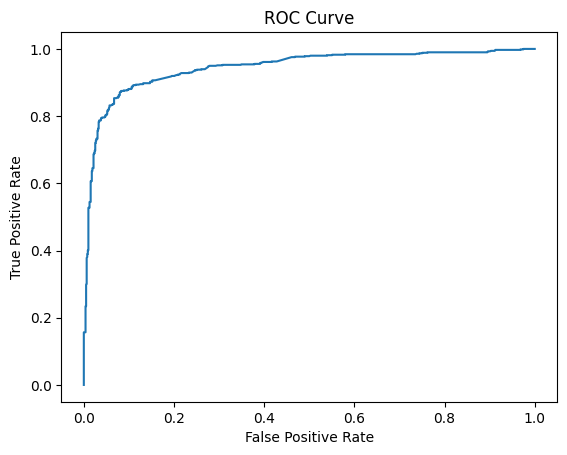

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [32]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.9443465371744506


In [33]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.9443465371744506


In [46]:
train_sizes, train_scores, test_scores = learning_curve(

    best_cat,

    X,

    y,

    cv=5,

    scoring='accuracy',

    train_sizes=np.linspace(0.1,1.0,5)

)

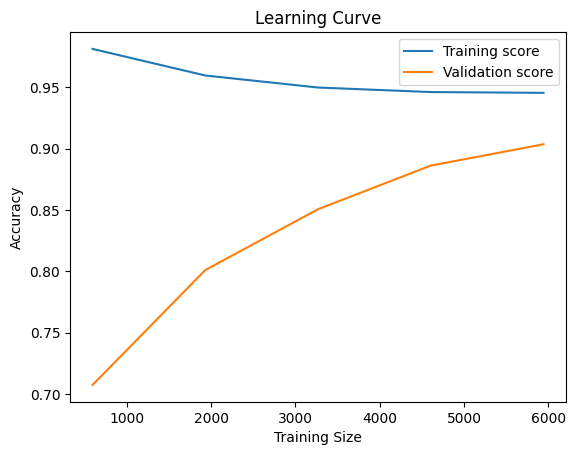

In [47]:
train_mean = np.mean(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training score")

plt.plot(train_sizes, test_mean, label="Validation score")

plt.xlabel("Training Size")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.show()

In [48]:
param_range = [4,6,8,10]

train_scores, test_scores = validation_curve(

    CatBoostClassifier(verbose=0),

    X,

    y,

    param_name="depth",

    param_range=param_range,

    cv=5,

    scoring="accuracy"

)

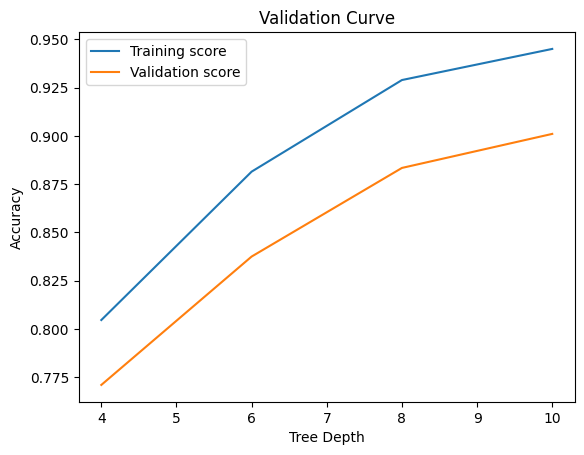

In [49]:
train_mean = np.mean(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)

plt.plot(param_range, train_mean, label="Training score")

plt.plot(param_range, test_mean, label="Validation score")

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.show()